# A. Data Loading

Pada bagian ini akan dilakukan import library dan file dataset untuk dilakukan eksplorasi sederhana. Sumber dataset juga dicantumkan, dari hasil data loading akan dilakukan pengecekan informasi untuk melihat kualitas data yang digunakan dan diberikan beberapa insight.

## Import Library dan File Data CSV

[Klik disini untuk melihat sumber data](https://www.kaggle.com/datasets/gazal5277/e-commerce-product-and-customer-dataset)

In [ ]:
# import library yang dibutuhkan
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Load data yang sudah disimpan dan lakukan copy pada data agar data asli tidak berubah, lalu lihat preview 5 baris teratas data

In [5]:
# read csv file yang sudah di save
data1 = pd.read_csv('refined_ecommerce_product_data.csv')

# duplicate data ori
df = data1.copy()

# Preview data
df.head()

,Product_ID,Product_Name,Category,Sub_Category,Price,Customer_Age,Customer_Gender,Purchase_History,Review_Rating,Review_Sentiment
0,P0001,Sweater,Clothing,Pants,38.44,58,Male,16,2,Negative
1,P0002,Dining Table,Furniture,Chair,408.46,53,Female,4,5,Very Positive
2,P0003,Skincare Cream,Beauty,Hair Care,22.04,54,Male,7,2,Negative
3,P0004,Skincare Cream,Beauty,Makeup,145.24,27,Female,21,4,Neutral
4,P0005,Bluetooth Speaker,Electronics,Headphones,862.61,44,Female,27,5,Very Positive


In [4]:
# Melihat baris dan kolom pada tabel
df.shape

(8000, 10)

Terdapat 8000 baris dan 10 kolom pada dataset.

In [5]:
# Melihat ringkasan dari dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product_ID        8000 non-null   object 
 1   Product_Name      8000 non-null   object 
 2   Category          8000 non-null   object 
 3   Sub_Category      8000 non-null   object 
 4   Price             8000 non-null   float64
 5   Customer_Age      8000 non-null   int64  
 6   Customer_Gender   8000 non-null   object 
 7   Purchase_History  8000 non-null   int64  
 8   Review_Rating     8000 non-null   int64  
 9   Review_Sentiment  8000 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 625.1+ KB


**Insight :**  

    - Terdapat 6 kolom bertipe object dan 4 kolom integer (1 tipe float pada kolom price)
    - Tidak ada Missing value dari dataset dilihat dari Non-Null Count
    - Jumlah baris 8000
    - Jumlah kolom 10

In [6]:
# Melihat total nilai unique setiap kolom
df.nunique()

Product_ID          8000
Product_Name          38
Category               6
Sub_Category          32
Price               7619
Customer_Age          48
Customer_Gender        2
Purchase_History      51
Review_Rating          5
Review_Sentiment       4
dtype: int64

In [7]:
df.Review_Sentiment.unique()

array(['Negative', 'Very Positive', 'Neutral', 'Positive'], dtype=object)

**Insight :**

    - Product_ID tidak ada data yang duplikat, bisa menjadi primary key
    - Terdapat 6 category dan juga 32 sub category
    - Review_Rating skala 1-5
    - Review_Sentiment terdiri dari Negative, Neutral, Positive dan Very Positive

---

# B. Data Cleaning

Tabel yang sudah diambil dari dataset tidak perlu di cleaning karena sudah dilakukan pengecekan menggunakan `.info` pada Data Loading sebelumnya tidak ditemukan adanya missing values. Namun untuk memastikan kebersihan data akan dilakukan pengecekan lebih lanjut.

In [7]:
# Preview data
df.head()

,Product_ID,Product_Name,Category,Sub_Category,Price,Customer_Age,Customer_Gender,Purchase_History,Review_Rating,Review_Sentiment
0,P0001,Sweater,Clothing,Pants,38.44,58,Male,16,2,Negative
1,P0002,Dining Table,Furniture,Chair,408.46,53,Female,4,5,Very Positive
2,P0003,Skincare Cream,Beauty,Hair Care,22.04,54,Male,7,2,Negative
3,P0004,Skincare Cream,Beauty,Makeup,145.24,27,Female,21,4,Neutral
4,P0005,Bluetooth Speaker,Electronics,Headphones,862.61,44,Female,27,5,Very Positive


In [8]:
# Merubah nama kolom
df = df.rename(columns={'Price':'Price($)'})
df

,Product_ID,Product_Name,Category,Sub_Category,Price($),Customer_Age,Customer_Gender,Purchase_History,Review_Rating,Review_Sentiment
0,P0001,Sweater,Clothing,Pants,38.44,58,Male,16,2,Negative
1,P0002,Dining Table,Furniture,Chair,408.46,53,Female,4,5,Very Positive
2,P0003,Skincare Cream,Beauty,Hair Care,22.04,54,Male,7,2,Negative
3,P0004,Skincare Cream,Beauty,Makeup,145.24,27,Female,21,4,Neutral
4,P0005,Bluetooth Speaker,Electronics,Headphones,862.61,44,Female,27,5,Very Positive
...,...,...,...,...,...,...,...,...,...,...
7995,P7996,Yoga Mat,Sports,Football,619.80,32,Male,26,5,Very Positive
7996,P7997,Refrigerator,Home Appliances,Air Conditioner,411.58,44,Male,16,5,Very Positive
7997,P7998,Basketball,Sports,Yoga Mat,761.51,62,Male,12,4,Positive
7998,P7999,Vacuum Cleaner,Home Appliances,Vacuum Cleaner,281.13,60,Male,15,4,Positive


---

# C. Analisis dan Perhitungan

### Produk apa saja yang memiliki rating 5 dan sentiment very positive?

In [9]:
# Melihat nama-nama produk
df.Product_Name.unique()

array(['Sweater', 'Dining Table', 'Skincare Cream', 'Bluetooth Speaker',
       'Chair', 'Bicycle', 'Nail Polish', 'Football', 'T-Shirt',
       'Refrigerator', 'Dishwasher', 'Cabinet', 'Vacuum Cleaner',
       'Wireless Mouse', 'Tennis Racket', 'Lipstick', 'Smartphone',
       'Pants', 'Air Conditioner', 'Shampoo', 'Soccer Ball', 'Laptop',
       'Headphones', 'Smartwatch', 'Shoes', 'Couch', 'Bookshelf',
       'Basketball', 'Washing Machine', 'Yoga Mat', 'Dress', 'Foundation',
       'Microwave', 'Tablet', 'Perfume', 'Jacket', 'Sofa', 'Jeans'],
      dtype=object)

Mencari tahu produk apa saja yang memiliki rating 5 dan review sentiment very positive menggunakan filtering dengan `.loc`

In [10]:
# Melakukan filtering
df.loc[df.Review_Sentiment.isin(['Very Positive'])][df.Review_Rating  == 5]

,Product_ID,Product_Name,Category,Sub_Category,Price($),Customer_Age,Customer_Gender,Purchase_History,Review_Rating,Review_Sentiment
1,P0002,Dining Table,Furniture,Chair,408.46,53,Female,4,5,Very Positive
4,P0005,Bluetooth Speaker,Electronics,Headphones,862.61,44,Female,27,5,Very Positive
10,P0011,Football,Sports,Tennis Racket,281.99,36,Male,30,5,Very Positive
14,P0015,Dishwasher,Home Appliances,Vacuum Cleaner,632.87,51,Male,0,5,Very Positive
35,P0036,Laptop,Electronics,Tablets,1154.45,65,Male,11,5,Very Positive
...,...,...,...,...,...,...,...,...,...,...
7987,P7988,Smartwatch,Electronics,Laptops,1381.34,27,Male,41,5,Very Positive
7988,P7989,Basketball,Sports,Tennis Racket,583.37,65,Female,18,5,Very Positive
7989,P7990,Smartphone,Electronics,Smartwatches,769.22,42,Male,30,5,Very Positive
7995,P7996,Yoga Mat,Sports,Football,619.80,32,Male,26,5,Very Positive


Selanjutnya dilakukan penjumlahan total produk yang telah diberi rating 5 oleh customer dan diurutkan dari yang paling terbesar

In [11]:
# Menghitung total customer yang memberikan rating pada produk dan diurutkan dari yang terbesar
df.loc[df.Review_Sentiment.isin(['Very Positive'])][df.Review_Rating  == 5].groupby('Product_Name').agg({'Review_Rating':'count'}).sort_values(by='Review_Rating', ascending=False)

,Review_Rating
Product_Name,
Wireless Mouse,57
Dining Table,57
Cabinet,56
Refrigerator,55
Headphones,54
Air Conditioner,53
Couch,53
Vacuum Cleaner,52
Bookshelf,52


Untuk memastikan penjumlahan produk yang diberikan rating oleh customer, kita tambahkan `.sum` untuk melihat hasil keseluruhan. Ternyata hasil sama dengan total baris pada tabel sebelumnya.

In [12]:
# Mengecek jumlah pada tabel dan hasil total
df.loc[df.Review_Sentiment.isin(['Very Positive'])][df.Review_Rating  == 5].groupby('Product_Name').agg({'Review_Rating':'count'}).sum()

Review_Rating    1164
dtype: int64

Selanjutnya melakukan data visualisasi untuk lebih mudah melihat urutan nama produk yang memiliki `rating 5` dan ulasan `Very Positive`

<Axes: ylabel='Product_Name'>

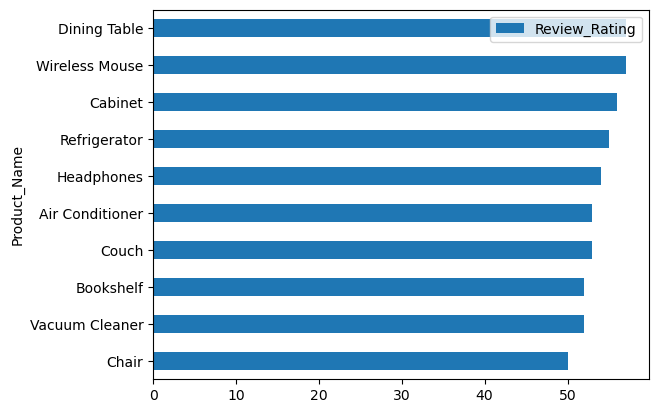

In [13]:
# Menampilkan visualisasi data dengan barchart
df.loc[df.Review_Sentiment.isin(['Very Positive'])][df.Review_Rating  == 5].groupby('Product_Name').agg({'Review_Rating':'count'}).sort_values(by='Review_Rating').tail(10).plot(kind='barh')

Dari hasil query filtering diketahui bahwa produk yang paling diminati ditempati oleh `Wireless Mouse` dan `Dining Table` dengan total produk muncul sebanyak 57 kali. Setelah diketahui produknya kita ingin melihat sebenarnya apa saja isi dalam produk tersebut dengan memfilter berdasarkan nama `Wireless Mouse` dan `Dining Table`.

In [14]:
# Filtering
df[(df.Product_Name == 'Wireless Mouse')]

,Product_ID,Product_Name,Category,Sub_Category,Price($),Customer_Age,Customer_Gender,Purchase_History,Review_Rating,Review_Sentiment
19,P0020,Wireless Mouse,Electronics,Tablets,1190.96,32,Female,20,4,Very Positive
57,P0058,Wireless Mouse,Electronics,Tablets,1417.75,38,Male,14,5,Very Positive
69,P0070,Wireless Mouse,Electronics,Speakers,875.37,22,Male,17,5,Very Positive
164,P0165,Wireless Mouse,Electronics,Headphones,79.13,61,Female,17,5,Neutral
181,P0182,Wireless Mouse,Electronics,Laptops,410.43,32,Female,19,4,Positive
...,...,...,...,...,...,...,...,...,...,...
7722,P7723,Wireless Mouse,Electronics,Mobile Phones,1284.25,32,Female,30,5,Very Positive
7800,P7801,Wireless Mouse,Electronics,Speakers,940.77,60,Female,13,5,Very Positive
7811,P7812,Wireless Mouse,Electronics,Headphones,577.33,44,Female,20,4,Very Positive
7959,P7960,Wireless Mouse,Electronics,Tablets,168.37,63,Female,12,5,Neutral


In [15]:
# Filtering
df[(df.Product_Name == 'Dining Table')]

,Product_ID,Product_Name,Category,Sub_Category,Price($),Customer_Age,Customer_Gender,Purchase_History,Review_Rating,Review_Sentiment
1,P0002,Dining Table,Furniture,Chair,408.46,53,Female,4,5,Very Positive
146,P0147,Dining Table,Furniture,Chair,1086.84,32,Female,17,4,Very Positive
186,P0187,Dining Table,Furniture,Sofa,174.51,36,Female,13,3,Positive
195,P0196,Dining Table,Furniture,Cabinet,346.74,57,Female,11,4,Very Positive
221,P0222,Dining Table,Furniture,Cabinet,883.72,25,Male,45,5,Very Positive
...,...,...,...,...,...,...,...,...,...,...
7918,P7919,Dining Table,Furniture,Sofa,301.49,59,Male,9,5,Very Positive
7932,P7933,Dining Table,Furniture,Chair,504.99,35,Female,25,5,Positive
7933,P7934,Dining Table,Furniture,Sofa,578.92,19,Female,28,5,Positive
7966,P7967,Dining Table,Furniture,Bookshelf,277.96,49,Male,19,4,Positive


Kesimpulannya pada kuartal ini banyak customer sedang membutuhkan barang-barang yang Categorynya `Elektronik` dan `Furniture`. Perusahaan dapat memperhatikan bagaimana produk-produk tersebut terjual kepada customer. Perusahaan dapat mempelajari jenis jasa pengiriman, bagaimana proses pelayanan dan juga promo apa saja yang diberikan oleh produk tersebut. Harapannya dengan melihat cara produk tersebut melayani customer, perusahaan dapat meningkatkan kepuasan pelanggan sehingga angka pembelian produk lainnya juga meningkat.

---

### Tampilkan produk yang paling diminati pria dan wanita!

Untuk melihat produk yang paling diminati oleh pria dan wanita. Filtering dilakukan terlebih dulu untuk melihat total pembelian produk yang dilakukan berdasarkan gender.

In [16]:
df.groupby(['Customer_Gender', 'Product_Name', 'Category']).sum()['Purchase_History']

Customer_Gender  Product_Name       Category       
Female           Air Conditioner    Home Appliances    2025
                 Basketball         Sports             2484
                 Bicycle            Sports             2013
                 Bluetooth Speaker  Electronics        1883
                 Bookshelf          Furniture          2029
                                                       ... 
Male             Tennis Racket      Sports             2262
                 Vacuum Cleaner     Home Appliances    2119
                 Washing Machine    Home Appliances    1812
                 Wireless Mouse     Electronics        1815
                 Yoga Mat           Sports             1844
Name: Purchase_History, Length: 76, dtype: int64

Setelah diketahui jumlah produk yang dibeli oleh masing-masing gender. Lakukan pengurutan berdasarkan riwayat pembelian sehingga dapat diketahui jumlah produk yang diminati oleh `Male` dan `Female`.

In [17]:
df.groupby(['Customer_Gender', 'Product_Name'])['Purchase_History'].sum().reset_index().sort_values(by='Purchase_History', ascending=False).head()


,Customer_Gender,Product_Name,Purchase_History
51,Male,Headphones,2588
1,Female,Basketball,2484
49,Male,Football,2424
34,Female,Vacuum Cleaner,2406
44,Male,Chair,2313


Dapat dilihat pada tabel sebelumnya, Pria lebih menyukai produk `Headphones` dan Wanita lebih menyukai produk `Basketball`. Untuk mempermudah perbandingan, lakukan visualisasi data menggunakan barchart.

<Axes: >

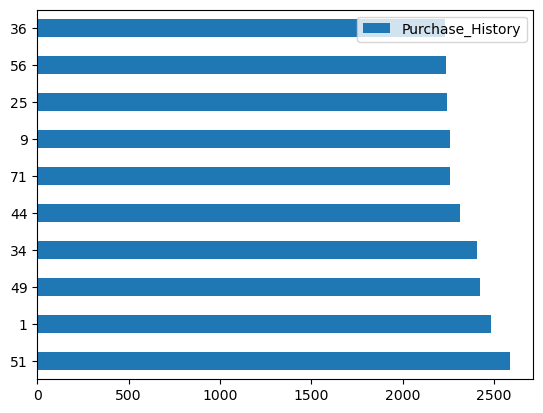

In [38]:
df.groupby(['Customer_Gender', 'Product_Name'])['Purchase_History'].sum().reset_index().sort_values(by='Purchase_History', ascending=False).head(10).plot(kind='barh')


Untuk melihat data apa saja yang berkaitan dengan `Headphones` dan `Basketball` dapat kita lakukan filtering sebagai berikut:

In [19]:
# Filtering
df[(df.Product_Name == 'Headphones')]

,Product_ID,Product_Name,Category,Sub_Category,Price($),Customer_Age,Customer_Gender,Purchase_History,Review_Rating,Review_Sentiment
36,P0037,Headphones,Electronics,Smartwatches,1146.26,29,Male,42,4,Very Positive
47,P0048,Headphones,Electronics,Speakers,309.54,46,Male,14,4,Positive
54,P0055,Headphones,Electronics,Tablets,407.96,48,Male,14,4,Very Positive
80,P0081,Headphones,Electronics,Speakers,1201.94,60,Male,15,4,Very Positive
85,P0086,Headphones,Electronics,Laptops,394.43,34,Female,13,5,Positive
...,...,...,...,...,...,...,...,...,...,...
7833,P7834,Headphones,Electronics,Mobile Phones,261.08,27,Female,9,4,Positive
7853,P7854,Headphones,Electronics,Headphones,984.43,35,Female,21,5,Positive
7878,P7879,Headphones,Electronics,Laptops,1275.68,18,Female,46,5,Very Positive
7904,P7905,Headphones,Electronics,Mobile Phones,287.53,32,Female,22,4,Positive


In [20]:
# Filtering
df[(df.Product_Name == 'Basketball')]

,Product_ID,Product_Name,Category,Sub_Category,Price($),Customer_Age,Customer_Gender,Purchase_History,Review_Rating,Review_Sentiment
61,P0062,Basketball,Sports,Football,552.77,35,Female,19,4,Positive
64,P0065,Basketball,Sports,Tennis Racket,599.39,53,Female,4,4,Very Positive
111,P0112,Basketball,Sports,Yoga Mat,418.13,63,Female,8,5,Very Positive
119,P0120,Basketball,Sports,Tennis Racket,83.10,51,Male,7,4,Neutral
123,P0124,Basketball,Sports,Football,230.54,28,Male,36,4,Positive
...,...,...,...,...,...,...,...,...,...,...
7984,P7985,Basketball,Sports,Football,30.60,18,Female,34,3,Neutral
7988,P7989,Basketball,Sports,Tennis Racket,583.37,65,Female,18,5,Very Positive
7991,P7992,Basketball,Sports,Basketball,96.27,48,Male,24,3,Neutral
7993,P7994,Basketball,Sports,Bicycle,36.63,62,Male,12,2,Negative


Diketahui bahwa Pria menyukai barang dengan kategori `electronics` sedangkan wanita menyukai produk dengan kategori `sports`. Hal ini memberikan insight bahwa perusahaan dapat meningkatkan angka pembelian masing-masing gender berdasarkan produk yang mereka minati yaitu `electronics` dan `sports`. Memberikan promo pada kategori tersebut diperkirakan bisa meningkatkan angka pembelian lebih tinggi lagi.

### Sebagai remaja (usia 18-21) produk apa saja yang paling diminati?

Usia remaja merupakan usia produktif yang dimana memiliki banyak kebutuhan namun juga masih belum memiliki banyak penghasilan. Maka dari itu dilakukan pencarian produk yang diminati oleh remaja kategori usia 18-21 dengan filtering sebagai berikut:

In [21]:
df.head()

,Product_ID,Product_Name,Category,Sub_Category,Price($),Customer_Age,Customer_Gender,Purchase_History,Review_Rating,Review_Sentiment
0,P0001,Sweater,Clothing,Pants,38.44,58,Male,16,2,Negative
1,P0002,Dining Table,Furniture,Chair,408.46,53,Female,4,5,Very Positive
2,P0003,Skincare Cream,Beauty,Hair Care,22.04,54,Male,7,2,Negative
3,P0004,Skincare Cream,Beauty,Makeup,145.24,27,Female,21,4,Neutral
4,P0005,Bluetooth Speaker,Electronics,Headphones,862.61,44,Female,27,5,Very Positive


In [22]:
df.loc[df.Customer_Age.isin([18,19,20,21])].groupby('Product_Name').agg({'Purchase_History':'sum'}).sort_values(by='Purchase_History', ascending=False).head()

,Purchase_History
Product_Name,
Football,998
Headphones,765
Sofa,747
Tennis Racket,668
Soccer Ball,666


Hasil dari filtering untuk usia 18-21 didapati produk dengan angka pembelian tertingga ada pada produk Football. Untuk dapat melihat lebih jelas dilakukan visualisasi data sebagai berikut.

<Axes: ylabel='Product_Name'>

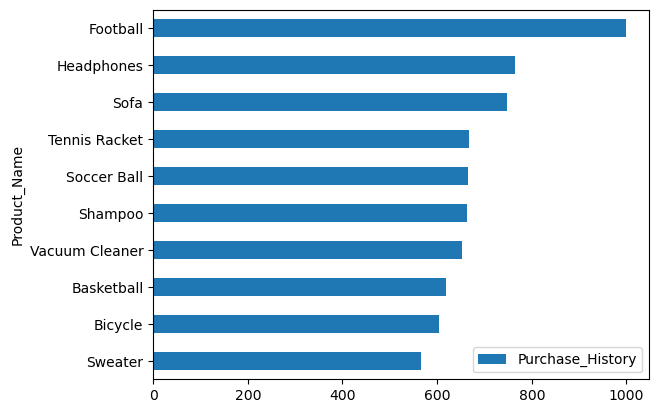

In [40]:
(df.loc[df.Customer_Age.isin([18,19,20,21])].groupby('Product_Name')).agg({'Purchase_History':'sum'}).sort_values(by='Purchase_History', ascending=True).tail(10).plot(kind='barh')

Untuk mengetahui data apa saja yang terdapat pada produk `Football` dilakukan filtering.

In [24]:
# Filtering
df[(df.Product_Name == 'Football')]

,Product_ID,Product_Name,Category,Sub_Category,Price($),Customer_Age,Customer_Gender,Purchase_History,Review_Rating,Review_Sentiment
10,P0011,Football,Sports,Tennis Racket,281.99,36,Male,30,5,Very Positive
13,P0014,Football,Sports,Tennis Racket,544.25,60,Male,17,5,Positive
21,P0022,Football,Sports,Tennis Racket,324.59,48,Male,24,4,Positive
23,P0024,Football,Sports,Bicycle,49.89,54,Male,19,1,Negative
29,P0030,Football,Sports,Bicycle,127.73,51,Female,18,4,Neutral
...,...,...,...,...,...,...,...,...,...,...
7856,P7857,Football,Sports,Yoga Mat,747.72,60,Male,6,4,Very Positive
7891,P7892,Football,Sports,Bicycle,153.41,26,Male,47,3,Positive
7907,P7908,Football,Sports,Basketball,680.23,53,Male,20,4,Very Positive
7926,P7927,Football,Sports,Yoga Mat,295.06,56,Female,13,5,Positive


Pada usia remaja, produk yang diminati berupa produk untuk keperluan olahraga. Untuk meningkatkan kepuasan pelanggan, perusahaan dapat memberikan promo-promo yang menargetkan pelanggan dengan usia remaja menggunakan ID identitas untuk memastikan pelanggan berusisa remaja. Promo-promo ini diharapkan dapat meningkatkan kepuasan pelanggan sehingga angka pembelian lebih tinggi lagi dan lebih dikenal oleh masyarakat luas.

### Berapa umur customer yang memiliki total pembelian tertinggi?

Dalam menentukan target pasar, mengetahui customer dengan total pembelian tertinggi diperlukan untuk dijadikan pelanggan tetap. Sehingga kepuasan pelanggan tersebut harus tetap dijaga untuk meningkatkan angka pembelian berkelanjutan.

In [25]:
#Preview data
df.head()

,Product_ID,Product_Name,Category,Sub_Category,Price($),Customer_Age,Customer_Gender,Purchase_History,Review_Rating,Review_Sentiment
0,P0001,Sweater,Clothing,Pants,38.44,58,Male,16,2,Negative
1,P0002,Dining Table,Furniture,Chair,408.46,53,Female,4,5,Very Positive
2,P0003,Skincare Cream,Beauty,Hair Care,22.04,54,Male,7,2,Negative
3,P0004,Skincare Cream,Beauty,Makeup,145.24,27,Female,21,4,Neutral
4,P0005,Bluetooth Speaker,Electronics,Headphones,862.61,44,Female,27,5,Very Positive


Dilakukan filtering sebagai berikut untuk mengurutkan umur pelanggan berdasarkan riwata pembelian.

In [26]:
df.groupby('Customer_Age')['Purchase_History'].sum().reset_index().sort_values(by='Purchase_History', ascending=False).head()

,Customer_Age,Purchase_History
9,27,5182
6,24,5129
8,26,4734
0,18,4717
2,20,4692


Diketahui bahwa pembelian terbanyak ada pada pelanggan yang berumur 27 tahun. Untuk dapat melihat lebih jelas dilakukan visualisasi data.

<Axes: ylabel='Customer_Age'>

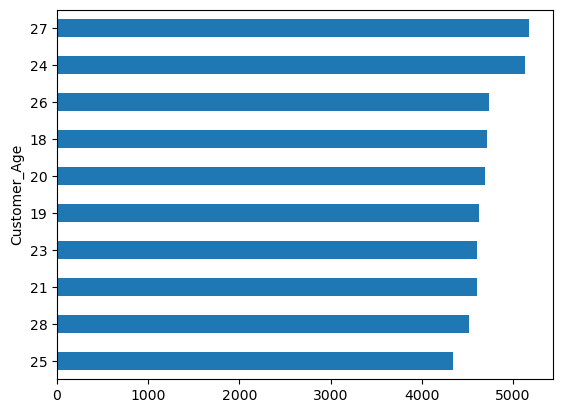

In [42]:
df.groupby('Customer_Age')['Purchase_History'].sum().sort_values().tail(10).plot(kind='barh')

Untuk mengetahui produk apa saja yang dibeli oleh pelanggan dengan umur 27 tahun dilakukan query sebagai berikut:

In [28]:
# Filtering
age_27 = df[(df.Customer_Age == 27)]
age_27

,Product_ID,Product_Name,Category,Sub_Category,Price($),Customer_Age,Customer_Gender,Purchase_History,Review_Rating,Review_Sentiment
3,P0004,Skincare Cream,Beauty,Makeup,145.24,27,Female,21,4,Neutral
20,P0021,Tennis Racket,Sports,Basketball,119.47,27,Female,25,3,Neutral
28,P0029,Smartphone,Electronics,Tablets,325.36,27,Female,29,4,Positive
103,P0104,Dress,Clothing,Shoes,96.79,27,Male,43,3,Positive
105,P0106,Smartwatch,Electronics,Smartwatches,947.76,27,Male,45,5,Very Positive
...,...,...,...,...,...,...,...,...,...,...
7833,P7834,Headphones,Electronics,Mobile Phones,261.08,27,Female,9,4,Positive
7865,P7866,Sweater,Clothing,T-Shirts,19.43,27,Female,7,1,Neutral
7973,P7974,Football,Sports,Basketball,109.25,27,Female,45,5,Neutral
7985,P7986,Bicycle,Sports,Tennis Racket,243.30,27,Male,27,4,Very Positive


In [29]:
# Data unique pada kolom category
age_27.Category.unique()

array(['Beauty', 'Sports', 'Electronics', 'Clothing', 'Furniture',
       'Home Appliances'], dtype=object)

Diketahui bahwa category produk yang disering dibeli oleh pelanggan dengan riwayat pembelian tertinggi adalah `Beauty, Sports, Electronics, Clothing, Furniture, Home Appliances`. Hal ini dapat memberikan insight bahwa umur 27 tahun adalah umur produktif yang ideal dimana keperluan hidup dan juga penghasilan berbanding setara sehingga semua kebutuhan dapat terpenuhi. Untuk kategori pelanggan berumur 27 tahun perusahaan dapat membuat sistem dimana member seperti usia 27 tahun ini diberikan peringkat contohnya peringkat teratas dari bronze, silver, gold dan platinum. Sistem peringkat ini diharapkan mampu memberikan pelanggan kepuasan dengan promo-promo yang lebih menarik agar kepuasan dan kenyaman pelanggan tetap terjaga yang dapat meningkatkan angka pembelian.

### Hitung rata-rata, median dan modus pada umur customer!

In [30]:
df.head()

,Product_ID,Product_Name,Category,Sub_Category,Price($),Customer_Age,Customer_Gender,Purchase_History,Review_Rating,Review_Sentiment
0,P0001,Sweater,Clothing,Pants,38.44,58,Male,16,2,Negative
1,P0002,Dining Table,Furniture,Chair,408.46,53,Female,4,5,Very Positive
2,P0003,Skincare Cream,Beauty,Hair Care,22.04,54,Male,7,2,Negative
3,P0004,Skincare Cream,Beauty,Makeup,145.24,27,Female,21,4,Neutral
4,P0005,Bluetooth Speaker,Electronics,Headphones,862.61,44,Female,27,5,Very Positive


In [31]:
print(f'Rata-rata umur customer : {df.Customer_Age.mean()}')
print(f'Median umur customer : {df.Customer_Age.median()}')
print(f'Modus umur customer : {df.Customer_Age.mode().values[0]}')

Rata-rata umur customer : 41.614125
Median umur customer : 42.0
Modus umur customer : 27


Dari data yang didapatkan diperkirakan distribusi penyebaran umur pelanggan pada kuartal kali ini terdistribusi secara normal. Hal ini dilihat dari hasil rata-rata dan median umur pelanggan yang hampir sama yaitu `41.6` dan `42`. Untuk modus pada umur didaptkan pada umu 27. Modus pada data pelanggan ini membuktian bahwa sesuai dengan umur pelanggan yang paling tinggi riwayat pembeliannya, pelanggan dengan umur 27 tahun juga menjadi modus pada kuartal ini.

### Apakah ada korelasi antara jenis kelamin dan review sentiment yang diberikan?

In [32]:
df.Review_Sentiment.unique()

array(['Negative', 'Very Positive', 'Neutral', 'Positive'], dtype=object)

Untuk mengetahui jumlah pria dan wanita yang menjadi pelanggan pada kuartal ini dilakukan code sebagai berikut:

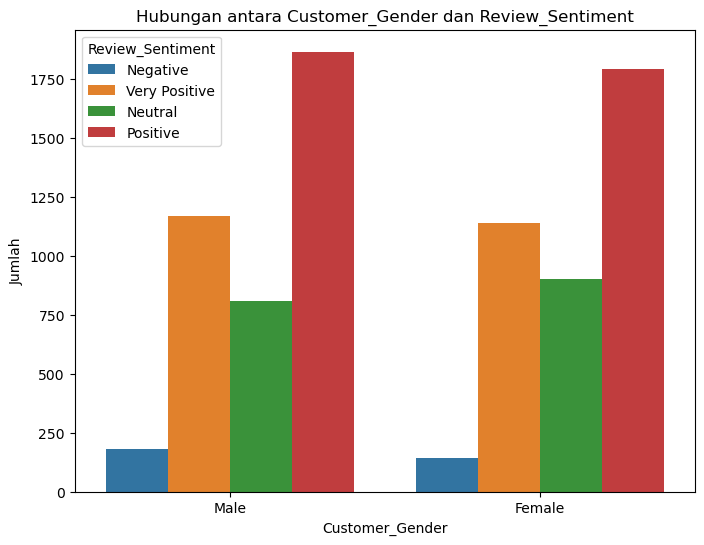

In [48]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Customer_Gender', hue='Review_Sentiment')
plt.title("Hubungan antara Customer_Gender dan Review_Sentiment")
plt.xlabel("Customer_Gender")
plt.ylabel("Jumlah")
plt.show()

In [33]:
df['Customer_Gender'].value_counts()

Customer_Gender
Male      4023
Female    3977
Name: count, dtype: int64

Karena membandingkan kategori dengan kategori dilakukan Hipotesis test `Chi-Squared Test` dengan hipotesis:

H0 : Tidak adanya hubungan antara gender dan review sentiment

H1 : Ada hubungan antara gender dan review sentiment

In [34]:
#Contingency Table
contingency_table = pd.crosstab(df['Customer_Gender'],df['Review_Sentiment'])
contingency_table

Review_Sentiment,Negative,Neutral,Positive,Very Positive
Customer_Gender,,,,
Female,144,902,1792,1139
Male,180,810,1866,1167


In [35]:
res = stats.chi2_contingency(contingency_table)
print("P-value:",res.pvalue)

P-value: 0.014647711843427547


Critical value: 0.05

p-value = 0.01 < critical value

H0 ditolak

Kesimpulan:

Ada hubungan antara gender dan review sentiment, dimana jika dilihat dari data review sentiment `Pria` lebih sering memberikan komentar jika dilihat dari total Review pada sentiment Negative, Positive dan Very Positive pria lebih mendominasi. Namun, untuk `wanita` lebih sering memberikan respon Neutral pada review sentiment.

Untuk melihat analisis korelasi antara `Customer_Gender` dan `Review_Sentiment` gunakan teknik korelasi kendall.

In [36]:
# Cek analisis korelasi
corr_tau, pval_k = stats.kendalltau(df['Customer_Gender'], df['Review_Sentiment'])

print(f"tau-correlation: {corr_tau:.2f}, p-value: {pval_k}")

tau-correlation: 0.01, p-value: 0.32170128361537176


Jika nilai p lebih dari 0,05, maka korelasi antara dua variabel tersebut adalah kebetulan.

0.3 > 0.05 maka korelasi terjadi secara kebetulan

Berdasarkan korelasi kendall `0.01` hasil didapatkan korelasi positif dimana nilai mendekati 0. Menunjukkan bahwa hampir tidak adanya korelasi antara `Customer_Gender` dan `Review_Sentiment`.



# D. Pengambilan Kesimpulan

Dari hasil analisa diatas dapat diketahui beberapa poin:

- Produk yang paling disukai oleh pelanggan adalah produk dengan category `Elektonics` dan `Furniture`. Perusahaan dapat mempelajari bagaimana produsen produk tersebut memberikan service kepada pelanggan sehingga disukai oleh banyak orang.

- Pria dan Wanita memiliki produk berbeda yang paling diminati, dimana pria menyukai produk dengan kategori `electronics` dan wanita menyukai kategori `sports`. Data ini dapat membantu perusahaan dalam menentukan produk apa saja yang bisa diberikan promo ataupun peningkatan pelayanan guna mencari pelanggan berdasarkan gendernya. Rekomendasi: Untuk hari event seperti hari ayah atau ibu, berikan promo pada produk dengan kedua kategori tersebut agar meningkatkan kepuasan pelanggan.

- Usia remaja (18-21 tahun), menyukai produk kategori `sports`. Perusahaan dapat menggunakan data ini untuk menarik pelanggan berusia remaja dengan memberikan promo yang menargetkan pelanggan berdasarkan umur menggunakan identitas ID mereka. Sehingga kepuasan pelanggan dengan umur remaja dapat meningkat dan perusahaan lebih dikenal oleh banyak masyarakat.

- Pelanggan dengan riwayat pembelian tertinggi ada pada umur 27 tahun. Perlunya kepuasan pada pelanggan dengan umur ini sangat dibutuhkan oleh perusahaan agar pelanggan tetap loyal membeli. Maka diperlukan sistem member dengan melihat total transaksi dimana jika peringkat member semakin tinggi akan memberikan promo yang lebih menarik pula. Hal ini diharapkan akan menjaga loyalitas pelanggan kepada perusahaan.

Kepuasan pelanggan adalah hal yang krusial dalam mempertahankan ataupun meningkatkan angka pembelian. Hasil analisa-analisa tadi diharapkan dapat meningkatkan kepuasan tiap pelanggan jika dapat diimplementasikan dengan benar. Dengan terciptanya kepuasan pelanggan, loyalitas pelanggan dapat meningkat dan menciptakan pembelian berulang. Pelanggan baru pun akan semakin berdatangan dengan informasi-informasi yang disebarkan oleh pelanggan yang telah loyal yang akan meningkatkan angka penjualan.


---

---
$$End$$
---